In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

np.random.seed(42)
N = 2000
X = np.random.uniform(-3, 3, (N, 3))
x1 = X[:, 0]
x2 = X[:, 1]
x3 = X[:, 2]

# Deterministic nonlinear function
Y = np.sin(x1) + x2**2 + np.log(1 + np.abs(x3)) + 0.5 * x1 * x3
Y = Y.reshape(-1, 1)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

X shape: (2000, 3)
Y shape: (2000, 1)


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(3,)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse')

history = model.fit(X, Y, epochs=200, batch_size=64, verbose=0)
losses = history.history['loss']

predictions = model.predict(X)
print(f"Final Loss: {losses[-1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Final Loss: 0.0082


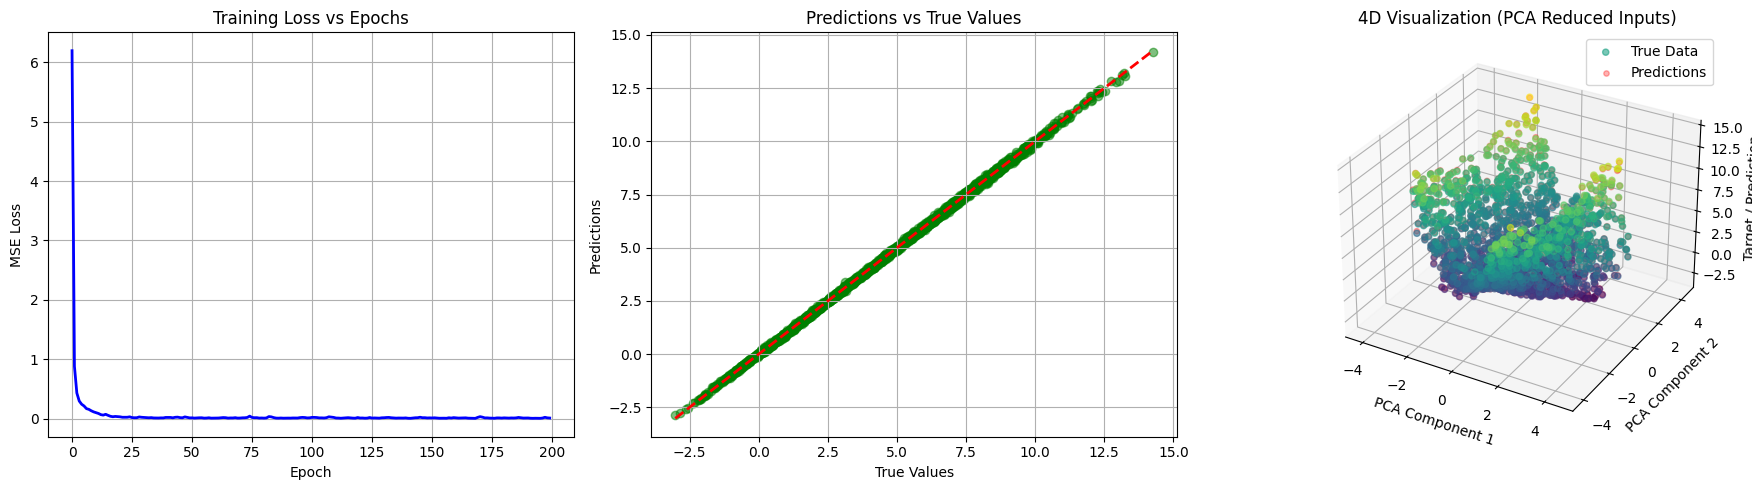

In [3]:
fig = plt.figure(figsize=(18, 5))

# Plot 1: Loss vs Epochs
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(losses, color='blue', linewidth=2)
ax1.set_title("Training Loss vs Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.grid(True)

# Plot 2: Predictions vs True Values
ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(Y, predictions, alpha=0.5, color='green')
ax2.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2)
ax2.set_title("Predictions vs True Values")
ax2.set_xlabel("True Values")
ax2.set_ylabel("Predictions")
ax2.grid(True)

# Plot 3: 4D Visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

ax3 = fig.add_subplot(1, 3, 3, projection='3d')
sc = ax3.scatter(X_pca[:, 0], X_pca[:, 1], Y.flatten(), c=Y.flatten(), cmap='viridis', alpha=0.6, label='True Data')
ax3.scatter(X_pca[:, 0], X_pca[:, 1], predictions.flatten(), color='red', alpha=0.3, s=15, label='Predictions')
ax3.set_title("4D Visualization (PCA Reduced Inputs)")
ax3.set_xlabel("PCA Component 1")
ax3.set_ylabel("PCA Component 2")
ax3.set_zlabel("Target / Prediction")
ax3.legend()

plt.tight_layout()
plt.show()